# Run for all col4 data

In [2]:
from pyowt.satellite_handlers.eumetsat_olci_level2 import eumetsat_olci_level2
from tqdm import tqdm
import glob
import os

sen3_dirs = glob.glob('/media/elbe/Data/satellite/hereon/*SEN3')
sen3_dirs = [d for d in sen3_dirs if os.path.isdir(d) and (os.path.basename(d).startswith('S3A') or os.path.basename(d).startswith('S3B'))]

for fn in tqdm(sen3_dirs, desc='Processing .SEN3 folders'):
    base = os.path.basename(fn)
    if base.startswith('S3A'):
        sensor = 'olci-s3a'
    elif base.startswith('S3B'):
        sensor = 'olci-s3b'
    else:
        continue  # skip if not S3A or S3B
    eumetsat = eumetsat_olci_level2(filename=fn, sensor=sensor)


Processing .SEN3 folders:   0%|          | 0/31 [00:00<?, ?it/s]/home/shun/Documents/GitHub/pyOWT/pyowt/satellite_handlers/eumetsat_olci_level2.py:140: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  ds_new = xr.merge(Ref_list)
/home/shun/Documents/GitHub/pyOWT/pyowt/satellite_handlers/eumetsat_olci_level2.py:140: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or s

# OWT Membership Statistics and Stacked Bar Plot

This cell reads all output NetCDF files, computes the statistics of `utot` for valid (flagged) pixels, classifies them into levels, and generates a stacked bar plot similar to the provided example.

Processing files: 100%|██████████| 31/31 [00:14<00:00,  2.07it/s]


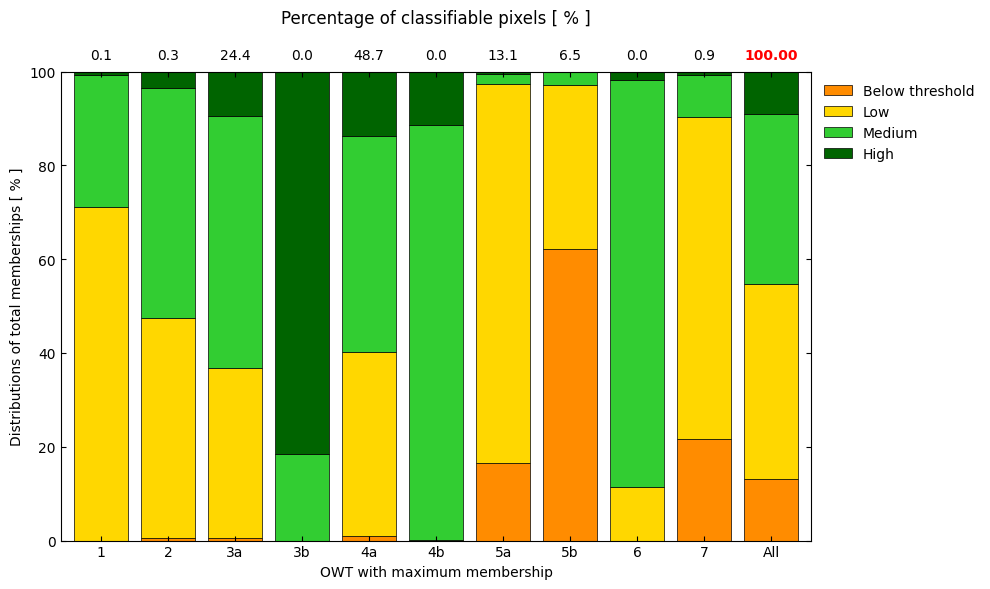

------------------------------
Total files processed: 31
Total valid pixels analyzed: 60,002,597
OWT 1: 34,952 pixels (0.06%)
OWT 2: 158,332 pixels (0.26%)
OWT 3a: 14,615,454 pixels (24.36%)
OWT 3b: 7,899 pixels (0.01%)
OWT 4a: 29,250,359 pixels (48.75%)
OWT 4b: 5,039 pixels (0.01%)
OWT 5a: 7,836,348 pixels (13.06%)
OWT 5b: 3,883,873 pixels (6.47%)
OWT 6: 1,052 pixels (0.00%)
OWT 7: 540,230 pixels (0.90%)
------------------------------


In [4]:
import glob
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

# OWT type mapping: Correcting labels to match the snapshot (3a/b, 4a/b, etc.)
x_labels = ["1", "2", "3a", "3b", "4a", "4b", "5a", "5b", "6", "7", "All"]
owt_indices = list(range(10))

# Membership level bins and updated colors to match visual style
level_bins = [0, 0.0001, 0.3, 0.8, 1.01]
level_labels = ["Below threshold", "Low", "Medium", "High"]
# Reordering colors to match the stack (Bottom: Orange -> Top: Dark Green)
level_colors = ["#FF8C00", "#FFD700", "#32CD32", "#006400"] 

# Find all output nc files
nc_files = glob.glob('/media/elbe/Data/satellite/hereon/*_owt.nc')

# Prepare stats: [type][level]
stats = np.zeros((11, 4))  # 10 OWTs + 1 for 'All', 4 levels
type_pixel_counts = np.zeros(11)

# Statistical processing
for nc in tqdm(nc_files, desc="Processing files"):
    ds = xr.open_dataset(nc)
    flag = ds['flag'].values
    type_idx = ds['type_idx'].values
    utot = ds['utot'].values

    # Only consider valid pixels
    mask = flag == 1
    type_idx_valid = type_idx[mask]
    utot_valid = utot[mask]

    # For each OWT type
    for i in owt_indices:
        idx_mask = type_idx_valid == i
        if np.any(idx_mask):
            utot_type = utot_valid[idx_mask]
            hist, _ = np.histogram(utot_type, bins=level_bins)
            stats[i] += hist
            type_pixel_counts[i] += np.sum(idx_mask)

    # For 'All'
    hist_all, _ = np.histogram(utot_valid, bins=level_bins)
    stats[10] += hist_all
    type_pixel_counts[10] += utot_valid.size
    ds.close()

# Convert to proportions
stats_prop = stats / stats.sum(axis=1, keepdims=True) * 100
# Percentage of classifiable pixels relative to the total valid pixels
type_prop = type_pixel_counts / type_pixel_counts[10] * 100

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
bottom = np.zeros(11)

for i, (label, color) in enumerate(zip(level_labels, level_colors)):
    ax.bar(range(11), stats_prop[:, i], bottom=bottom, color=color, label=label, edgecolor='black', linewidth=0.5)
    bottom += stats_prop[:, i]

# Add top numbers outside the box
for i, val in enumerate(type_prop):
    color = 'red' if i == 10 else 'black'
    fontweight = 'bold' if i == 10 else 'normal'
    # Placing text above the 100% line
    ax.text(i, 102, f"{val:.2f}" if i == 10 else f"{val:.1f}", 
            ha='center', va='bottom', color=color, fontweight=fontweight, clip_on=False)

# Axis formatting
ax.set_xticks(range(11))
ax.set_xticklabels(x_labels)
ax.set_yticks(np.arange(0, 101, 20))
ax.set_ylim(0, 100)
ax.set_xlim(-0.6, 10.6)

# Labels and Title
ax.set_ylabel("Distributions of total memberships [ % ]")
ax.set_xlabel("OWT with maximum membership")
ax.set_title("Percentage of classifiable pixels [ % ]", pad=35)

# Legend positioning
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), frameon=False)

# Tick adjustments to match the "inside" style
ax.tick_params(direction='in', top=True, right=True)

plt.tight_layout()
plt.savefig('col4_classifiability.png', dpi=400, bbox_inches='tight')
plt.show()

# Text Statistics Output
print("-" * 30)
print(f"Total files processed: {len(nc_files)}")
print(f"Total valid pixels analyzed: {int(type_pixel_counts[10]):,}")
for i, label in enumerate(x_labels[:-1]):
    print(f"OWT {label}: {int(type_pixel_counts[i]):,} pixels ({type_prop[i]:.2f}%)")
print("-" * 30)